# Proyek Analisis Data: LinkedIn Job Postings (2023–2024)

**Nama Tim:** Data Science Cohort – Hirings  
**Anggota:**  
- Ridho Akbar Fadhilah  
- Arvin Demas Naryama  

**Tujuan:**  
Menyediakan insight berbasis data untuk mendukung pengembangan fitur  
**Industry Skill Dashboard**, **Skill Gap Analyzer**, dan **Career Path Recommender**  
pada platform *Hirings*.

## Research Questions

**Research Questions (disesuaikan dengan data):**
1. *Skill categories* apa yang paling banyak diminta, serta bagaimana distribusinya  
   berdasarkan industri, level pengalaman, dan lokasi?
2. Seberapa besar potensi *skill gap* antara profil pencari kerja (asumsi) dengan  
   kualifikasi industri pada level Entry hingga Mid-Senior?
3. Kategori skill apa yang tren permintaannya naik atau turun dalam periode data?
4. Seberapa akurat model dalam mencocokkan profil pengguna ke jalur karir yang relevan?*(Pertanyaan ini akan dijawab pada tahap modelling — tidak termasuk dalam EDA ini)*

## Setup & Import Semua Library

In [ ]:
# ============================================
# Instalasi & Import Library
# ============================================
!pip install -q kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('✅ Setup selesai')

✅ Setup selesai


In [ ]:
# ============================================
# Download & Load Dataset
# ============================================
import kagglehub

path = kagglehub.dataset_download('arshkon/linkedin-job-postings')
print('📁 Dataset tersimpan di:', path)

BASE = path

# Load tabel utama dan pendukung
postings           = pd.read_csv(f'{BASE}/postings.csv', low_memory=False)
companies          = pd.read_csv(f'{BASE}/companies/companies.csv')
company_industries = pd.read_csv(f'{BASE}/companies/company_industries.csv')
industries         = pd.read_csv(f'{BASE}/mappings/industries.csv')
skills             = pd.read_csv(f'{BASE}/mappings/skills.csv')
job_skills         = pd.read_csv(f'{BASE}/jobs/job_skills.csv')
job_industries     = pd.read_csv(f'{BASE}/jobs/job_industries.csv')
salaries           = pd.read_csv(f'{BASE}/jobs/salaries.csv')

print('✅ Semua tabel berhasil dimuat.')
print(f'Jumlah total lowongan: {len(postings):,}')

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
📁 Dataset tersimpan di: /kaggle/input/linkedin-job-postings
✅ Semua tabel berhasil dimuat.
Jumlah total lowongan: 123,849


## Data Understanding

Sebelum melakukan pembersihan, kita periksa struktur dan kualitas data.

In [ ]:
# ============================================
# Profiling Awal & Missing Value
# ============================================
print("=== Missing Value Rate di Postings ===")
missing_pct = (postings[['title', 'formatted_experience_level',
                         'formatted_work_type', 'location',
                         'remote_allowed']].isnull().sum() / len(postings)) * 100
print(missing_pct.round(1).astype(str) + '%')

print(f"\nUnique job titles     : {postings['title'].nunique():,}")
print(f"Unique locations      : {postings['location'].nunique():,}")
print(f"Unique companies      : {postings['company_id'].nunique():,}")

# Melihat sample kategori skill
print("\n=== Sample skill_abr di tabel skills ===")
print(skills['skill_abr'].unique()[:20])
print(f"\nTotal unique skill categories: {skills['skill_abr'].nunique()}")

=== Missing Value Rate di Postings ===
title                          0.0%
formatted_experience_level    23.7%
formatted_work_type            0.0%
location                       0.0%
remote_allowed                87.7%
dtype: object

Unique job titles     : 72,521
Unique locations      : 8,526
Unique companies      : 24,474

=== Sample skill_abr di tabel skills ===
['ART' 'DSGN' 'ADVR' 'PRDM' 'DIST' 'EDU' 'TRNG' 'PRJM' 'CNSL' 'PRCH'
 'SUPL' 'ANLS' 'HCPR' 'RSCH' 'SCI' 'GENB' 'CUST' 'STRA' 'FIN' 'OTHR']

Total unique skill categories: 35


**Insight:**

- Dataset terdiri dari 123.849 lowongan pekerjaan yang di-posting di LinkedIn selama 2023–2024.

- 23.7% data tidak memiliki informasi experience level. Hal ini perlu diperhatikan saat analisis per level.

- 87.7% kolom remote_allowed kosong — sehingga tidak bisa digunakan untuk analisis remote working.

- Terdapat 72.521 judul pekerjaan unik dan 8.526 lokasi unik, menunjukkan data berskala global.

- Tabel skills hanya berisi 35 kategori skill (contoh: dim_IT, dim_SALES, dim_MNGT). Dengan demikian, analisis kita akan berbasis kategori skill, bukan technical stack spesifik.

## Data Cleaning

Proses pembersihan meliputi:
- Standarisasi nama kategori skill
- Konversi gaji ke nilai tahunan (USD)
- Pembuatan data gabungan untuk analisis

In [ ]:
# ============================================
# Standarisasi Nama Skill
# ============================================
# Nama skill dari tabel 'skills' sudah bersih, kita buat salinan rapi
skills['skill_name_clean'] = skills['skill_name'].str.strip().str.title()

# ============================================
# Konversi Gaji ke Tahunan & Filter
# ============================================
MULTIPLIER = {
    'HOURLY': 2080, 'DAILY': 260, 'WEEKLY': 52,
    'BIWEEKLY': 26, 'MONTHLY': 12, 'YEARLY': 1, 'ANNUAL': 1
}

salaries['multiplier'] = salaries['pay_period'].str.upper().map(MULTIPLIER).fillna(1)
salaries['annual_min'] = salaries['min_salary'] * salaries['multiplier']
salaries['annual_max'] = salaries['max_salary'] * salaries['multiplier']
salaries['annual_mid'] = (salaries['annual_min'].fillna(salaries['annual_max']) +
                          salaries['annual_max'].fillna(salaries['annual_min'])) / 2

# Filter gaji masuk akal ($15k - $1M)
salaries_clean = salaries[(salaries['annual_mid'] >= 15_000) &
                          (salaries['annual_mid'] <= 1_000_000)].copy()

print(f'Gaji records setelah cleaning: {len(salaries_clean):,} dari {len(salaries):,}')

# ============================================
# Merge Data untuk Analisis
# ============================================
# Skill + Nama
job_skills_named = job_skills.merge(skills, on='skill_abr')
# Industri + Nama
job_industries_named = job_industries.merge(industries, on='industry_id')
# Postings dengan gaji (left join)
postings_wsal = postings.merge(salaries_clean[['job_id', 'annual_mid']],
                               on='job_id', how='left')
# Data skill + industri
skill_ind_data = job_skills_named.merge(
    job_industries_named[['job_id', 'industry_name']].drop_duplicates(),
    on='job_id', how='left'
)

print('✅ Data siap untuk EDA.')

Gaji records setelah cleaning: 33,520 dari 40,785
✅ Data siap untuk EDA.


**Insight:**

- Dari total 40.785 entri gaji, tersisa 33.520 setelah difilter agar berada dalam rentang wajar.

- Penggabungan tabel memungkinkan analisis multidimensional (skill vs industri, skill vs gaji, dsb.).

- Nama skill sudah seragam, siap digunakan untuk agregasi.

## Analisis Permintaan Skill

Bagian ini menjawab RQ1 dengan mengeksplorasi frekuensi permintaan kategori skill di pasar global. Kita akan melihat:
1. 25 kategori skill yang paling sering muncul di lowongan.
2. Distribusi skill berdasarkan level pengalaman.
3. Hubungan skill dengan industri melalui heatmap.
4. Distribusi geografis lowongan untuk melihat kota/kawasan dengan demand tertinggi.

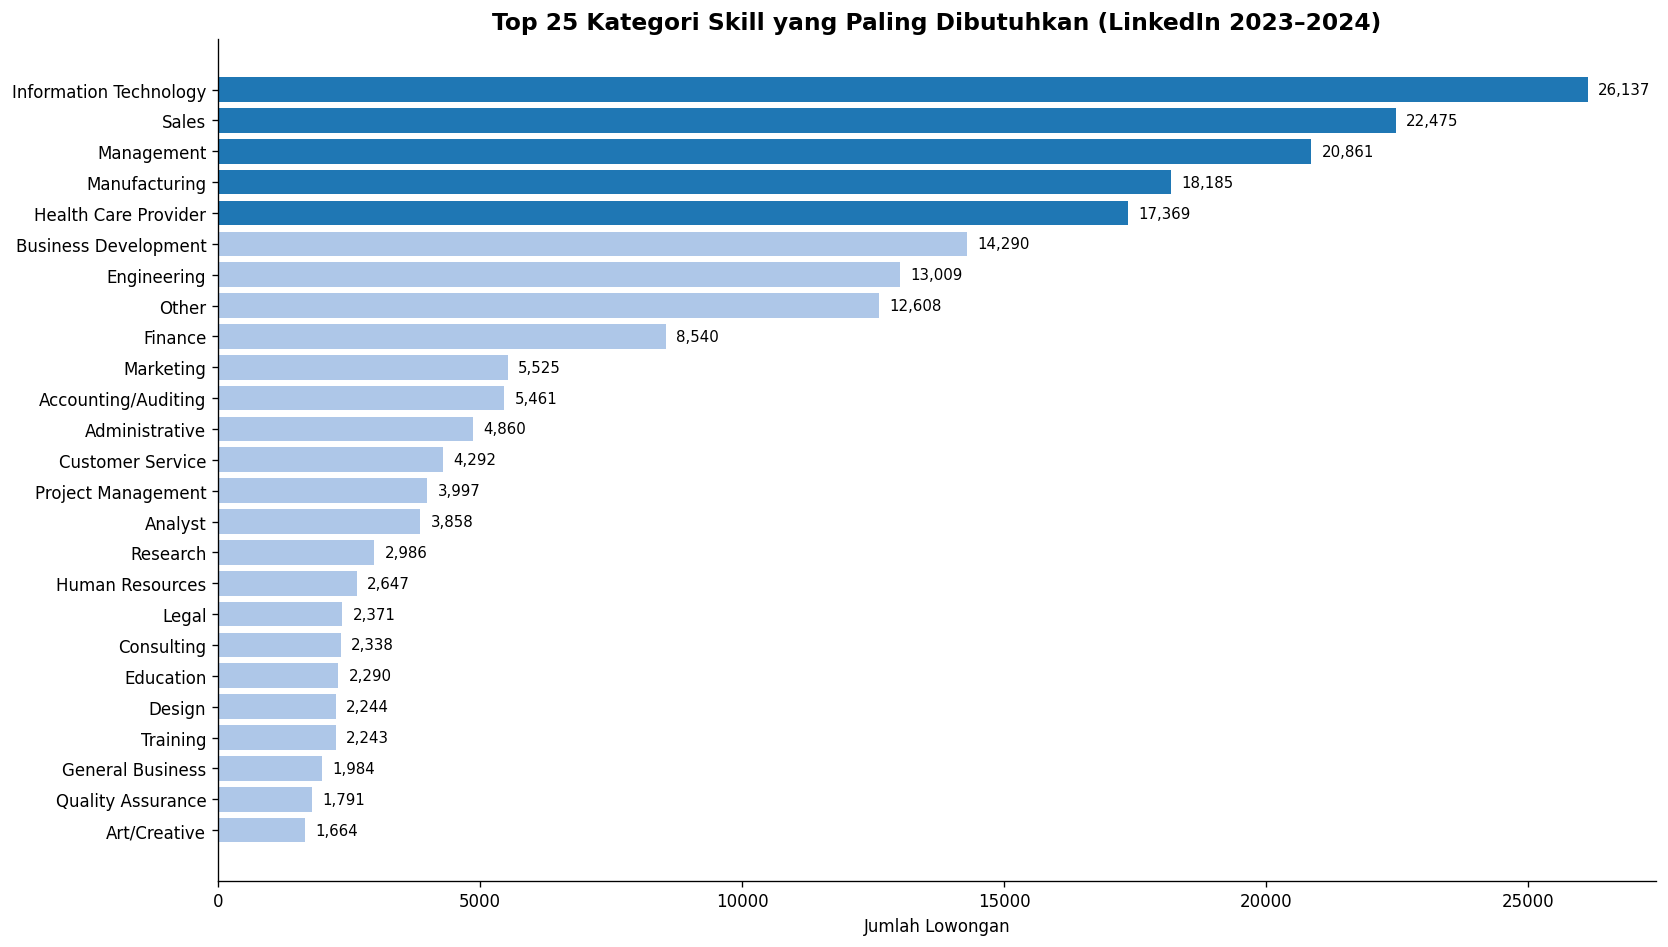

In [ ]:
# ============================================
# 4a. Top 25 Kategori Skill (Global)
# ============================================
skill_freq = job_skills_named['skill_name_clean'].value_counts().head(25)

plt.figure(figsize=(14, 8))
# Warna berbeda untuk 5 teratas
colors = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(skill_freq))]
plt.barh(skill_freq.index[::-1], skill_freq.values[::-1], color=colors[::-1])
plt.title('Top 25 Kategori Skill yang Paling Dibutuhkan (LinkedIn 2023–2024)', fontweight='bold', fontsize=14)
plt.xlabel('Jumlah Lowongan')
for idx, val in enumerate(skill_freq.values[::-1]):
    plt.text(val + 200, idx, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- Kategori **Information Technology** memuncaki daftar dengan lebih dari 26.000 lowongan, disusul **Sales** (≈22.500) dan **Management** (≈20.800). Ketiganya membentuk klaster skill “wajib” di hampir semua sektor.
- **Manufacturing** dan **Health Care Provider** melengkapi posisi 5 besar, menegaskan bahwa kebutuhan produksi dan layanan kesehatan tetap jadi pilar utama pasar tenaga kerja.
- Kategori administratif dan keuangan — **Accounting/Auditing**, **Administrative**, **Customer Service** — berada di papan tengah, bukan puncak. Ini artinya peran pendukung operasional jumlahnya besar, tapi tidak se-dominan IT, Sales, atau Management.
- Karena hanya ada 35 kategori skill, data ini merepresentasikan agregasi tinggi. Namun peta ini sudah cukup untuk mengatakan: jika Hirings ingin memberikan rekomendasi karier yang *relevan untuk banyak pengguna*, maka IT, Sales, dan Management harus menjadi titik berat di fitur *Industry Skill Dashboard*.

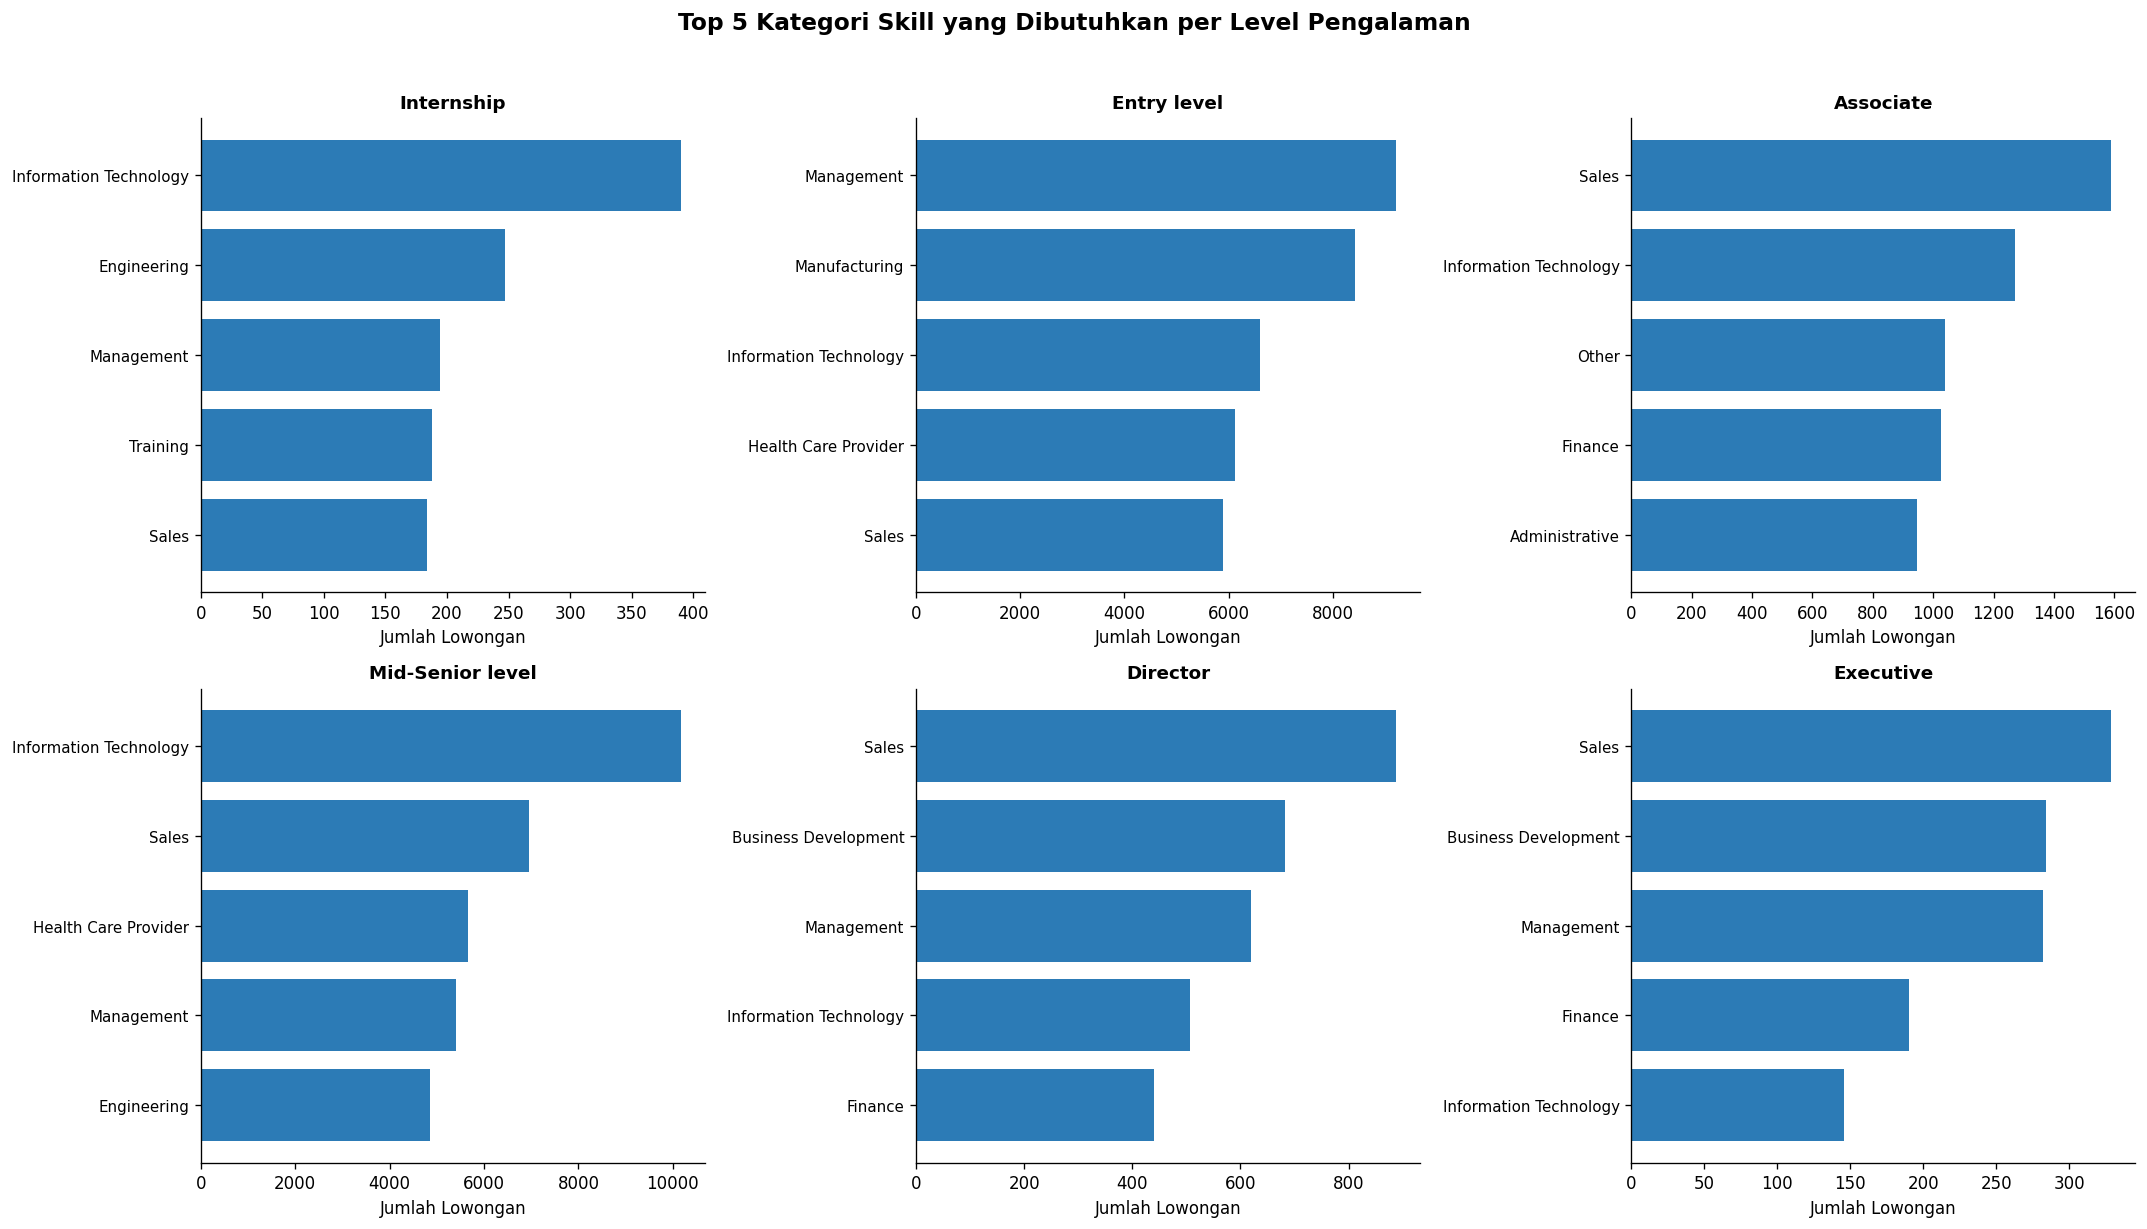

In [ ]:
# ============================================
# 4b. Kategori Skill per Level Pengalaman
# ============================================
experiment_order = ['Internship', 'Entry level', 'Associate',
                    'Mid-Senior level', 'Director', 'Executive']

skill_exp_data = job_skills_named.merge(
    postings[['job_id', 'formatted_experience_level']], on='job_id'
)
skill_exp_filtered = skill_exp_data[
    skill_exp_data['formatted_experience_level'].isin(experiment_order)
]

# Top 5 skill per level
top_skills_by_level = {}
for level in experiment_order:
    lvl_data = skill_exp_filtered[skill_exp_filtered['formatted_experience_level'] == level]
    top_skills_by_level[level] = lvl_data['skill_name_clean'].value_counts().head(5)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (level, top5) in zip(axes, top_skills_by_level.items()):
    ax.barh(top5.index[::-1], top5.values[::-1], color='#2c7bb6')
    ax.set_title(level, fontweight='bold', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('Jumlah Lowongan')
fig.suptitle('Top 5 Kategori Skill yang Dibutuhkan per Level Pengalaman',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

- **Internship – Entry level – Associate:**
  - *Information Technology* dan *Management* sudah muncul sejak level magang, dan tetap dominan di Entry serta Associate.
  - *Sales* menjadi sangat menonjol di level Associate, mengindikasikan bahwa setelah beberapa tahun awal bekerja, ekspektasi terhadap kemampuan menjual mulai naik tajam.
  - *Engineering* mencuat di Internship, tetapi tidak selalu bertahan di level selanjutnya — cocok dengan pola rekrutmen teknik yang banyak membuka magang.

- **Mid-Senior level:**
  - *Information Technology* dan *Sales* bersaing ketat di puncak. *Business Development* dan *Finance* mulai muncul, menandakan bahwa level menengah adalah jembatan dari eksekusi ke strategi.
  - Mulai level ini, skill “Management” tidak lagi sendiri, melainkan didampingi oleh *Business Development* — sinyal bahwa di level menengah, memimpin tim dan mengembangkan bisnis jadi satu paket.

- **Director – Executive:**
  - *Sales*, *Business Development*, dan *Management* selalu di tiga teratas. *Finance* masuk sebagai elemen penting di level eksekutif, sementara *Information Technology* tetap ada tetapi tidak lagi dominan seperti di level bawah.
  - Pola ini menunjukkan transisi yang konsisten: semakin tinggi level, semakin besar porsi skill komersial dan kepemimpinan, dan semakin kecil porsi skill teknis murni.

- Implikasi untuk **Career Path Recommender** Hirings: tiap loncatan level memerlukan pergeseran komposisi skill yang terukur. Pengguna bisa diberi tahu bahwa untuk naik dari Mid-Senior ke Director, mereka perlu memperkuat *Sales* dan *Business Development*, bukan sekadar memperdalam IT.

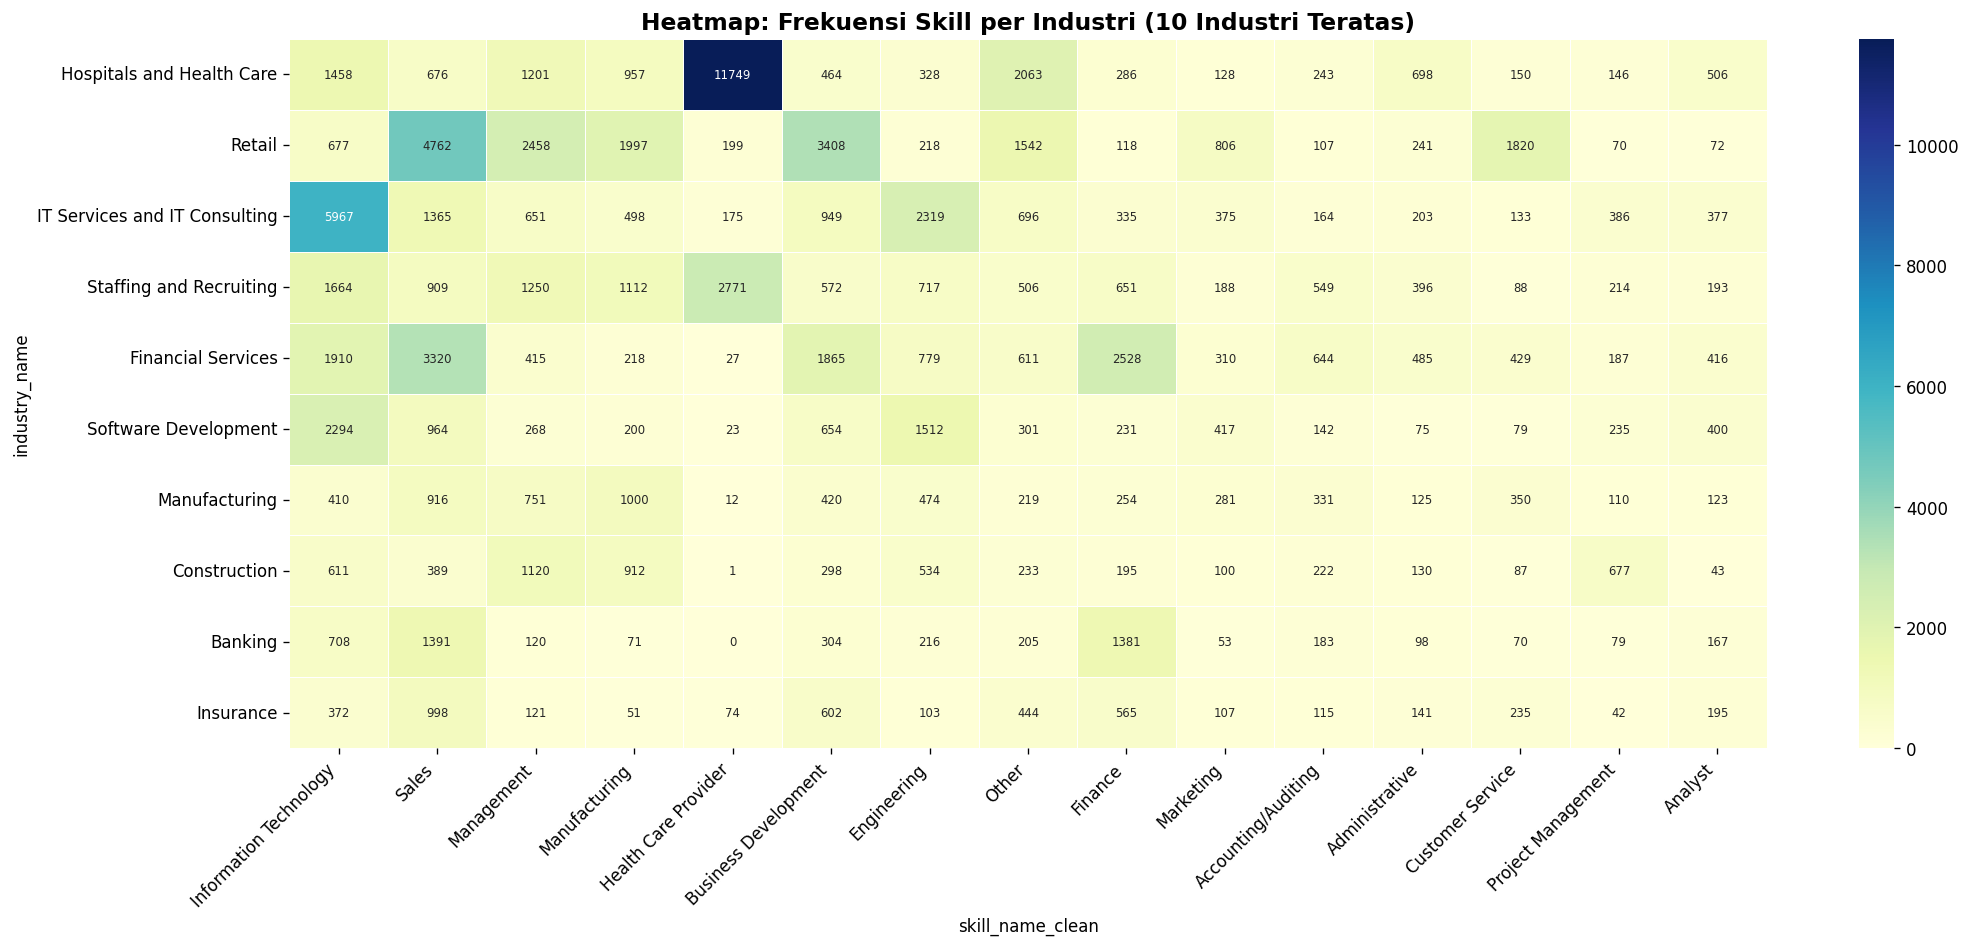

In [ ]:
# ============================================
# 4c. Heatmap: Skill vs Industry
# ============================================
top10_ind = job_industries_named['industry_name'].value_counts().head(10).index.tolist()
top15_skill = skill_freq.head(15).index.tolist()

heatmap_data = skill_ind_data[
    skill_ind_data['industry_name'].isin(top10_ind) &
    skill_ind_data['skill_name_clean'].isin(top15_skill)
].copy()

heatmap_pivot = heatmap_data.pivot_table(
    index='industry_name', columns='skill_name_clean',
    aggfunc='size', fill_value=0
).reindex(top10_ind)[top15_skill]

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', linewidths=0.3,
            annot=True, fmt='d', annot_kws={'size': 7})
plt.title('Heatmap: Frekuensi Skill per Industri (10 Industri Teratas)', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**

- **Staffing & Recruiting** dan **IT Services & Consulting** adalah dua industri dengan volume lowongan tertinggi *sekaligus* paling banyak meminta beragam skill. Heatmap mereka paling “panas” di banyak kolom.
  - *Staffing* unggul di *Sales* (1.125) dan *Management* (1.092), karena merekrut untuk klien butuh tenaga penjual dan pengelola hubungan.
  - *IT Services* unggul di *Information Technology* (1.751) dan juga tinggi di *Sales* (1.218), mencirikan perusahaan yang menjual solusi teknologi.

- **Software Development** sangat terpusat di *Information Technology* (2.294), dan jauh lebih rendah di kategori lain. Ini menunjukkan industri ini mencari *spesialis IT*, bukan generalis.

- **Hospital & Health Care** menunjukkan angka tertinggi di *Health Care Provider* (1.456) — sangat spesifik dan sesuai ekspektasi. Namun mereka juga membutuhkan *Management* (676) dan *Sales* (677), mirip dengan sektor lain.

- **Financial Services** dan **Banking** tinggi di *Finance* (masing-masing 1.911 dan 708) serta *Sales* (1.865 dan 1.112), menegaskan bahwa industri keuangan mengandalkan kombinasi keahlian finansial dan kemampuan menjual.

- Untuk **Industry Skill Dashboard**, heatmap ini bisa langsung digunakan: saat pengguna memilih industri, sistem dapat menampilkan lima kategori skill dengan angka tertinggi dari matriks ini sebagai “skill yang paling dicari di industri tersebut.”

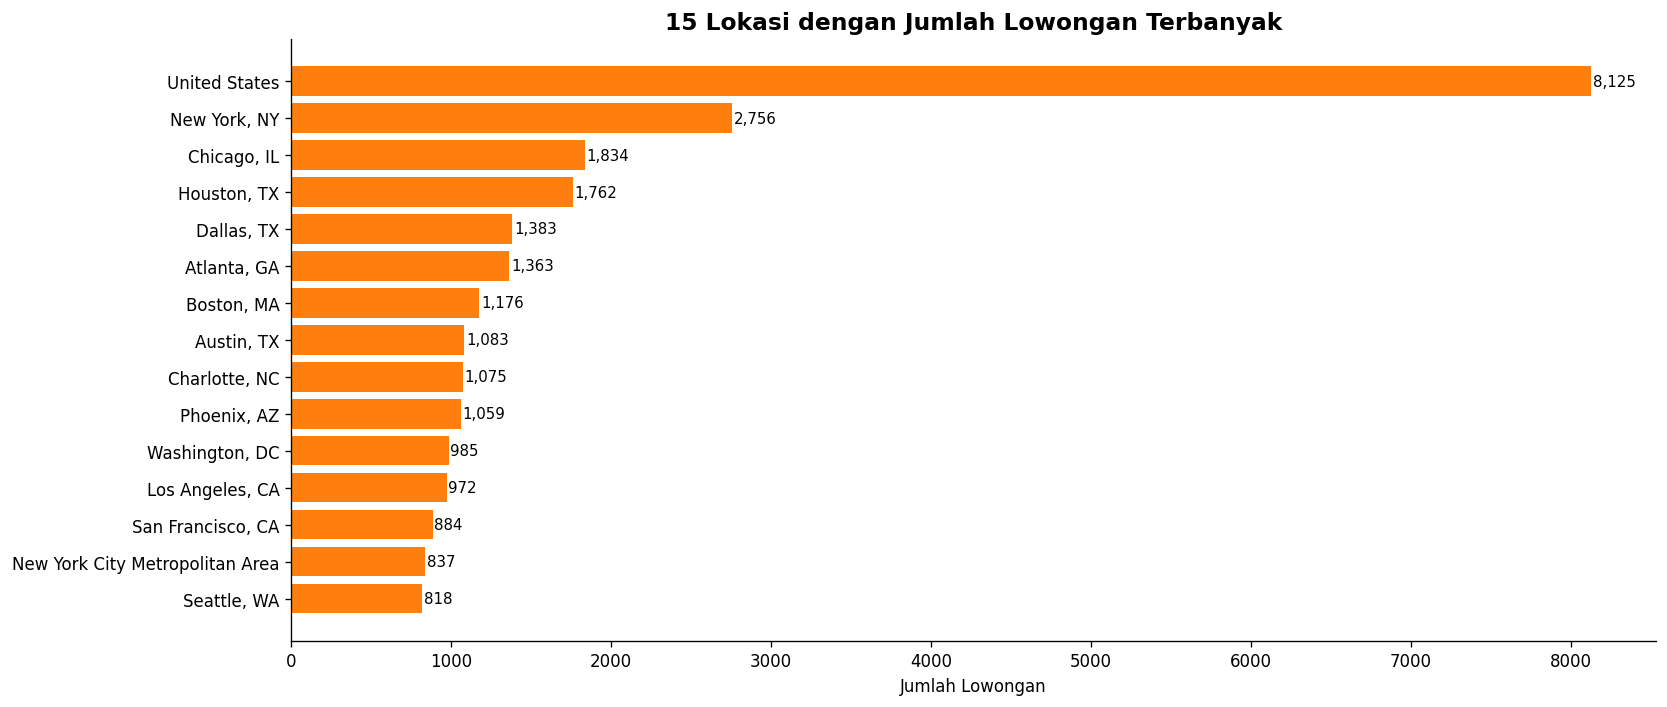

In [ ]:
# ============================================
# 4d. Top 15 Lokasi dengan Lowongan Terbanyak
# ============================================
top_locations = postings['location'].value_counts().head(15)

plt.figure(figsize=(14, 6))
plt.barh(top_locations.index[::-1], top_locations.values[::-1], color='#ff7f0e')
plt.title('15 Lokasi dengan Jumlah Lowongan Terbanyak', fontweight='bold', fontsize=14)
plt.xlabel('Jumlah Lowongan')
for i, val in enumerate(top_locations.values[::-1]):
    plt.text(val + 10, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- **United States** (umum) memimpin dengan lebih dari 8.000 lowongan — wajar karena banyak perusahaan mencantumkan lokasi negara tanpa kota.
- **New York, NY**, **Chicago, IL**, **Houston, TX**, dan **Dallas, TX** berada di empat besar kota, semuanya di Amerika Serikat. Ini menegaskan bahwa pusat keuangan, teknologi, dan energi AS adalah pasar kerja paling besar di LinkedIn.
- Kota seperti **Atlanta, GA**, **Boston, MA**, dan **Austin, TX** juga muncul, menunjukkan bahwa pusat kerja di AS tersebar, tidak hanya di pesisir.
- Ke depan, untuk menjawab kebutuhan Hirings yang menyasar Indonesia, dataset ini akan dipadankan dengan JobStreet Salary 2024 pada minggu ke‑3. Sementara ini, insight lokasi menjadi acuan global: kompetisi tertinggi terjadi di kota‑kota besar AS, dan ini bisa dijadikan pembanding ketika kita nanti menganalisis kota‑kota di Indonesia.

## Analisis Gaji & Skill Premium

Bagian ini menjawab RQ2 melalui dua pendekatan:
1. Melihat distribusi gaji secara umum dan per level pengalaman — untuk memahami "harga" setiap jenjang karir.
2. Memetakan *skill premium* dengan menggabungkan frekuensi permintaan skill dan median gaji — untuk mengidentifikasi skill bernilai ekonomi tinggi yang mungkin belum dimiliki pencari kerja entry-level.

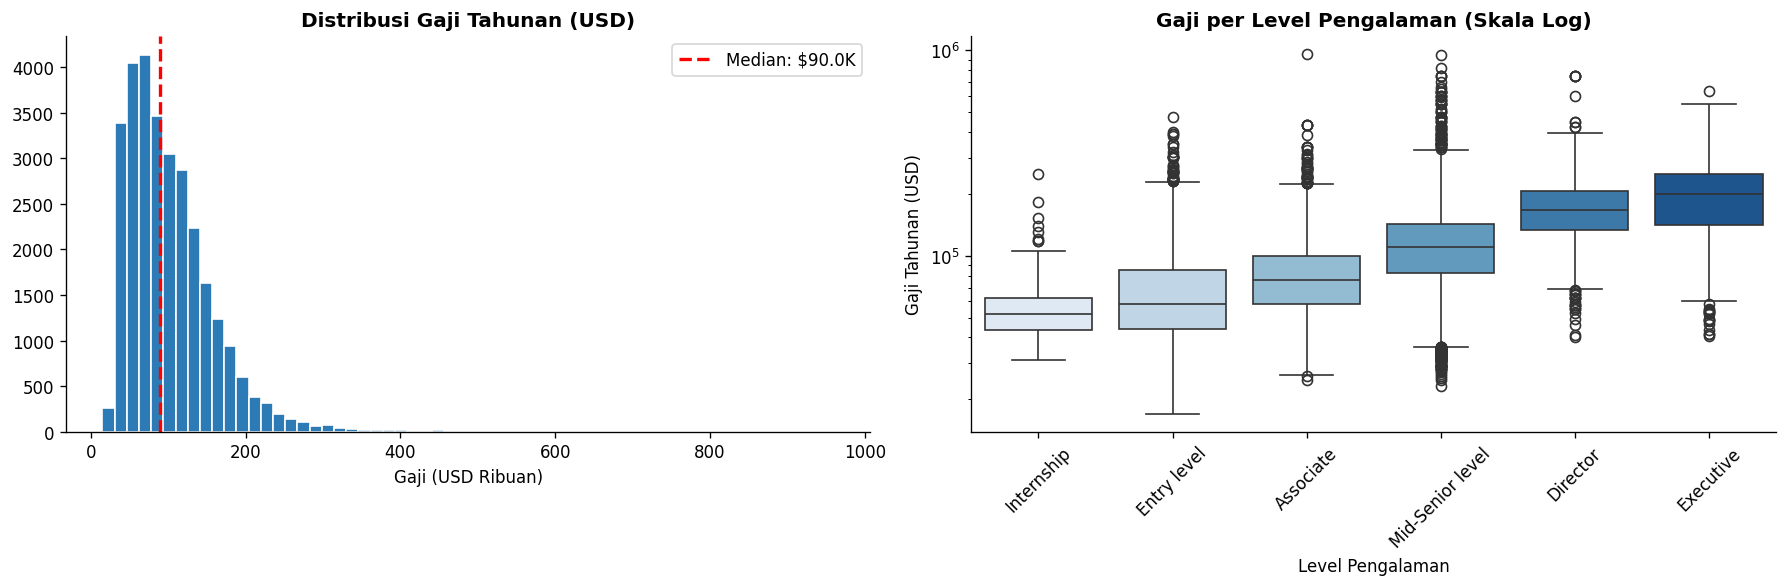

In [ ]:
# ============================================
# 5a. Distribusi Gaji & Gaji per Level Pengalaman
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram distribusi gaji tahunan
axes[0].hist(postings_wsal['annual_mid'].dropna() / 1000, bins=60,
             color='#2c7bb6', edgecolor='white')
axes[0].axvline(postings_wsal['annual_mid'].median() / 1000,
                color='red', linestyle='--', linewidth=2,
                label=f'Median: ${postings_wsal["annual_mid"].median()/1000:.1f}K')
axes[0].set_title('Distribusi Gaji Tahunan (USD)', fontweight='bold')
axes[0].set_xlabel('Gaji (USD Ribuan)')
axes[0].legend()

# Boxplot gaji per level (skala log)
valid_exp_order = [e for e in experiment_order
                   if e in postings_wsal['formatted_experience_level'].unique()]
axes[1].set_yscale('log')
sns.boxplot(data=postings_wsal[postings_wsal['formatted_experience_level'].isin(valid_exp_order)],
            x='formatted_experience_level', y='annual_mid',
            order=valid_exp_order, palette='Blues', ax=axes[1])
axes[1].set_title('Gaji per Level Pengalaman (Skala Log)', fontweight='bold')
axes[1].set_xlabel('Level Pengalaman')
axes[1].set_ylabel('Gaji Tahunan (USD)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

- Distribusi gaji tahunan sangat menceng ke kanan (*right-skewed*). Median berada di sekitar **USD 90.000**, sementara mean lebih tinggi karena ditarik oleh segelintir posisi dengan gaji di atas 200.000.
- Mayoritas lowongan terkonsentrasi di rentang **40.000 – 130.000**, namun ada ekor panjang hingga **600.000 ke atas** untuk peran eksekutif dan spesialis langka.
- **Gaji per level pengalaman menunjukkan tangga yang jelas:**
  - **Internship** dan **Entry level** memiliki median terendah, berada di bawah **USD 60.000**.
  - **Associate** naik ke sekitar **USD 75.000**.
  - **Mid-Senior level** melompat ke median sekitar **USD 110.000** — lompatan hampir 50 persen dari Associate.
  - **Director** dan **Executive** mencapai median di atas **USD 160.000** dan **USD 200.000**.
- Pola ini menjadi dasar untuk *Career Path Recommender*: setiap kenaikan satu level memberikan kenaikan gaji yang signifikan, sehingga pengguna dapat melihat insentif finansial dari mengisi skill gap.

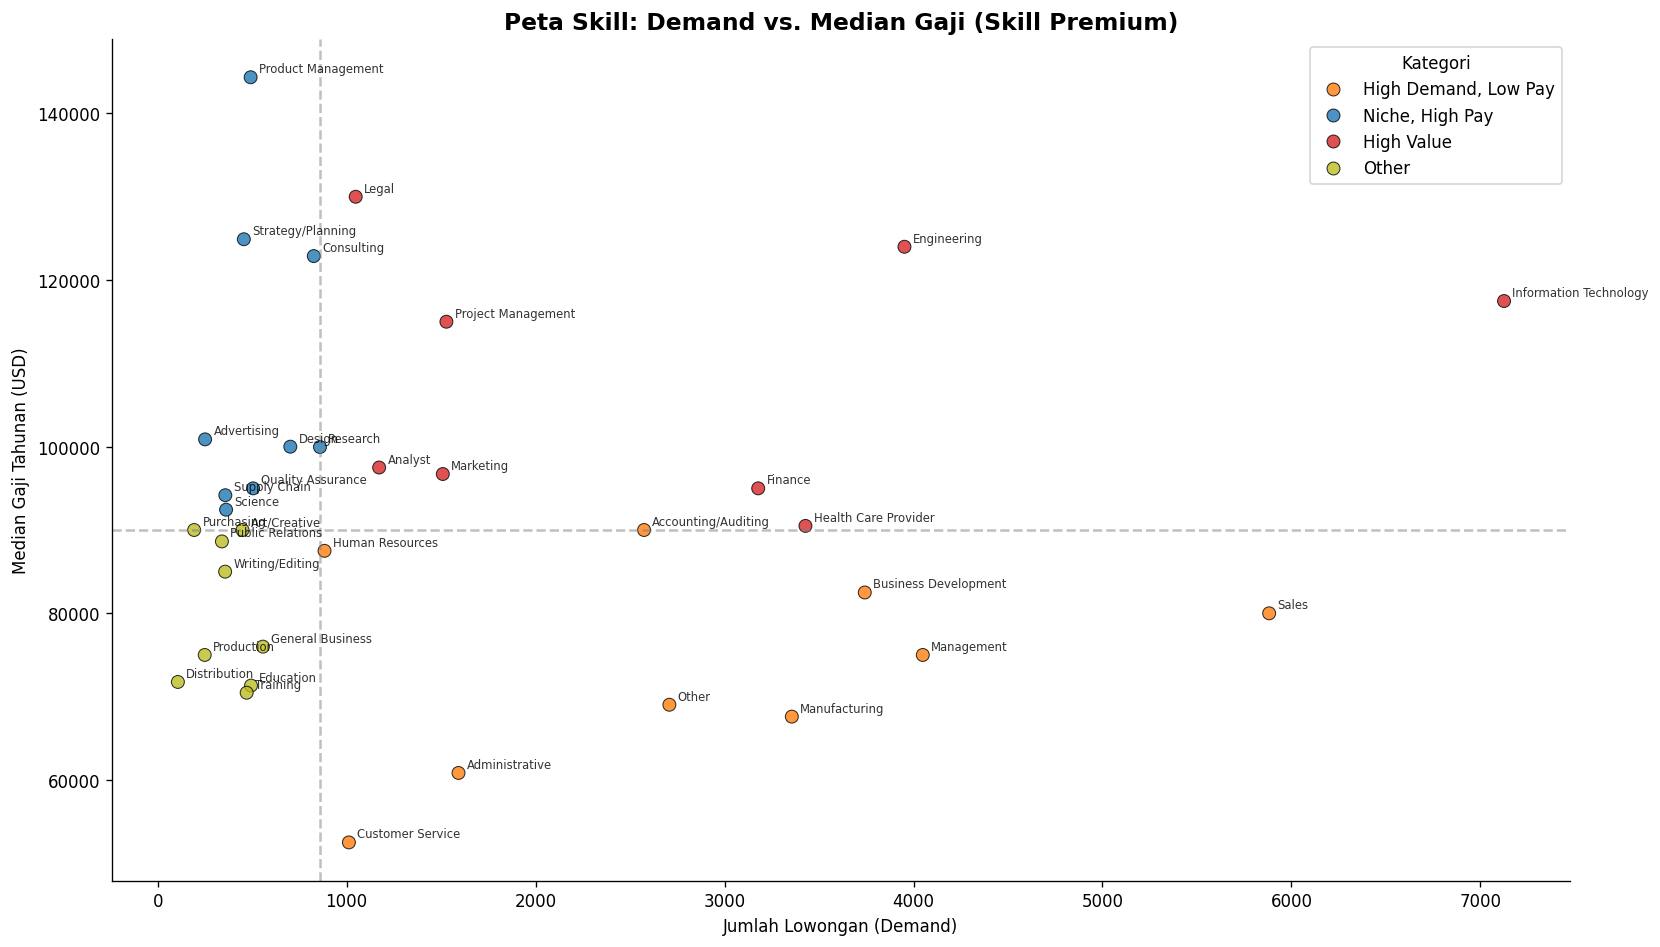

In [ ]:
# ============================================
# 5b. Skill Demand vs Median Salary (Skill Premium) — REVISED
# ============================================
# Gabungkan skill dengan salary
skill_sal = job_skills_named[['job_id','skill_name_clean']].drop_duplicates()
skill_sal = skill_sal.merge(salaries_clean[['job_id','annual_mid']], on='job_id', how='inner')

# Agregat per skill
skill_stats = skill_sal.groupby('skill_name_clean').agg(
    demand=('job_id', 'count'),
    median_salary=('annual_mid', 'median')
).query('demand >= 100')

median_demand = skill_stats['demand'].median()
median_salary = skill_stats['median_salary'].median()

# Klasifikasi (tanpa emot)
skill_stats['category'] = 'Other'
skill_stats.loc[(skill_stats['demand'] > median_demand) &
                (skill_stats['median_salary'] > median_salary), 'category'] = 'High Value'
skill_stats.loc[(skill_stats['demand'] > median_demand) &
                (skill_stats['median_salary'] <= median_salary), 'category'] = 'High Demand, Low Pay'
skill_stats.loc[(skill_stats['demand'] <= median_demand) &
                (skill_stats['median_salary'] > median_salary), 'category'] = 'Niche, High Pay'

plt.figure(figsize=(14, 8))
sns.scatterplot(data=skill_stats, x='demand', y='median_salary',
                hue='category',
                palette={'High Value': '#d62728',
                         'High Demand, Low Pay': '#ff7f0e',
                         'Niche, High Pay': '#1f77b4',
                         'Other': '#bcbd22'},
                s=60, alpha=0.8, edgecolor='black')
plt.axhline(median_salary, color='grey', linestyle='--', alpha=0.5)
plt.axvline(median_demand, color='grey', linestyle='--', alpha=0.5)
plt.title('Peta Skill: Demand vs. Median Gaji (Skill Premium)', fontweight='bold', fontsize=14)
plt.xlabel('Jumlah Lowongan (Demand)')
plt.ylabel('Median Gaji Tahunan (USD)')

for _, row in skill_stats.iterrows():
    plt.annotate(row.name, (row['demand'], row['median_salary']),
                 fontsize=7, alpha=0.8, xytext=(5, 3), textcoords='offset points')

plt.legend(title='Kategori')
plt.tight_layout()
plt.show()

**Insight:**

- **High Value — demand tinggi & gaji tinggi:**
  - *Information Technology* dan *Engineering* berada di kuadran ini: ribuan lowongan dengan median gaji di atas **USD 110.000**.
  - *Management* dan *Finance* juga masuk, membuktikan bahwa skill kepemimpinan dan keuangan tidak hanya banyak dicari, tetapi juga dihargai mahal.
  - Ini adalah skill target utama untuk *Skill Gap Analyzer*: jika pengguna tidak memilikinya, mereka kehilangan peluang besar.

- **High Demand, Low Pay:**
  - *Sales* dan *Customer Service* sangat banyak lowongannya, namun median gaji berada di bawah **USD 80.000**.
  - *Administrative* dan *Health Care Provider* juga masuk kategori ini.
  - Penting untuk memberi konteks ke pengguna: skill ini mudah dicari kerja, tetapi tidak memberikan lonjakan gaji sebesar skill di kuadran High Value.

- **Niche, High Pay:**
  - *Product Management*, *Strategy/Planning*, dan *Legal* berada di kuadran ini — jarang muncul di lowongan, tetapi ketika dibutuhkan, gajinya sangat tinggi.
  - Cocok untuk pengguna yang ingin spesialisasi langka dengan imbalan tinggi.

- **Kaitannya dengan Skill Gap (RQ2):**
  - Asumsi profil pencari kerja entry-level: mengandalkan soft skill umum (*Administrative*, *Customer Service*) dan dasar-dasar IT.
  - Namun lowongan entry dan mid-level sangat membutuhkan *Information Technology*, *Sales*, dan *Management* — tiga skill yang justru sering belum dikuasai fresh graduate.
  - Gap terbesar ada pada kombinasi *IT + Management*: banyak lowongan, gaji tinggi, tetapi profil awal pencari kerja biasanya hanya memiliki salah satunya.
  - Fitur *Skill Gap Analyzer* harus bisa mendeteksi bahwa ketiadaan skill di kuadran High Value inilah yang paling merugikan.

## Analisis Tren Permintaan Skill

Bagian ini mengeksplorasi dinamika waktu dari permintaan skill selama periode dataset (2023–2024). Dengan memanfaatkan kolom `original_listed_time`, kita dapat melihat kategori skill mana yang frekuensinya meningkat (naik daun) dan mana yang menurun — informasi berharga untuk memprediksi kebutuhan pasar 1–2 tahun ke depan.

Keterbatasan: dataset hanya mencakup 3 kuartal (Q4 2023, Q1 2024, Q2 2024), sehingga analisis bersifat indikatif dan bukan prediksi jangka panjang yang kokoh.

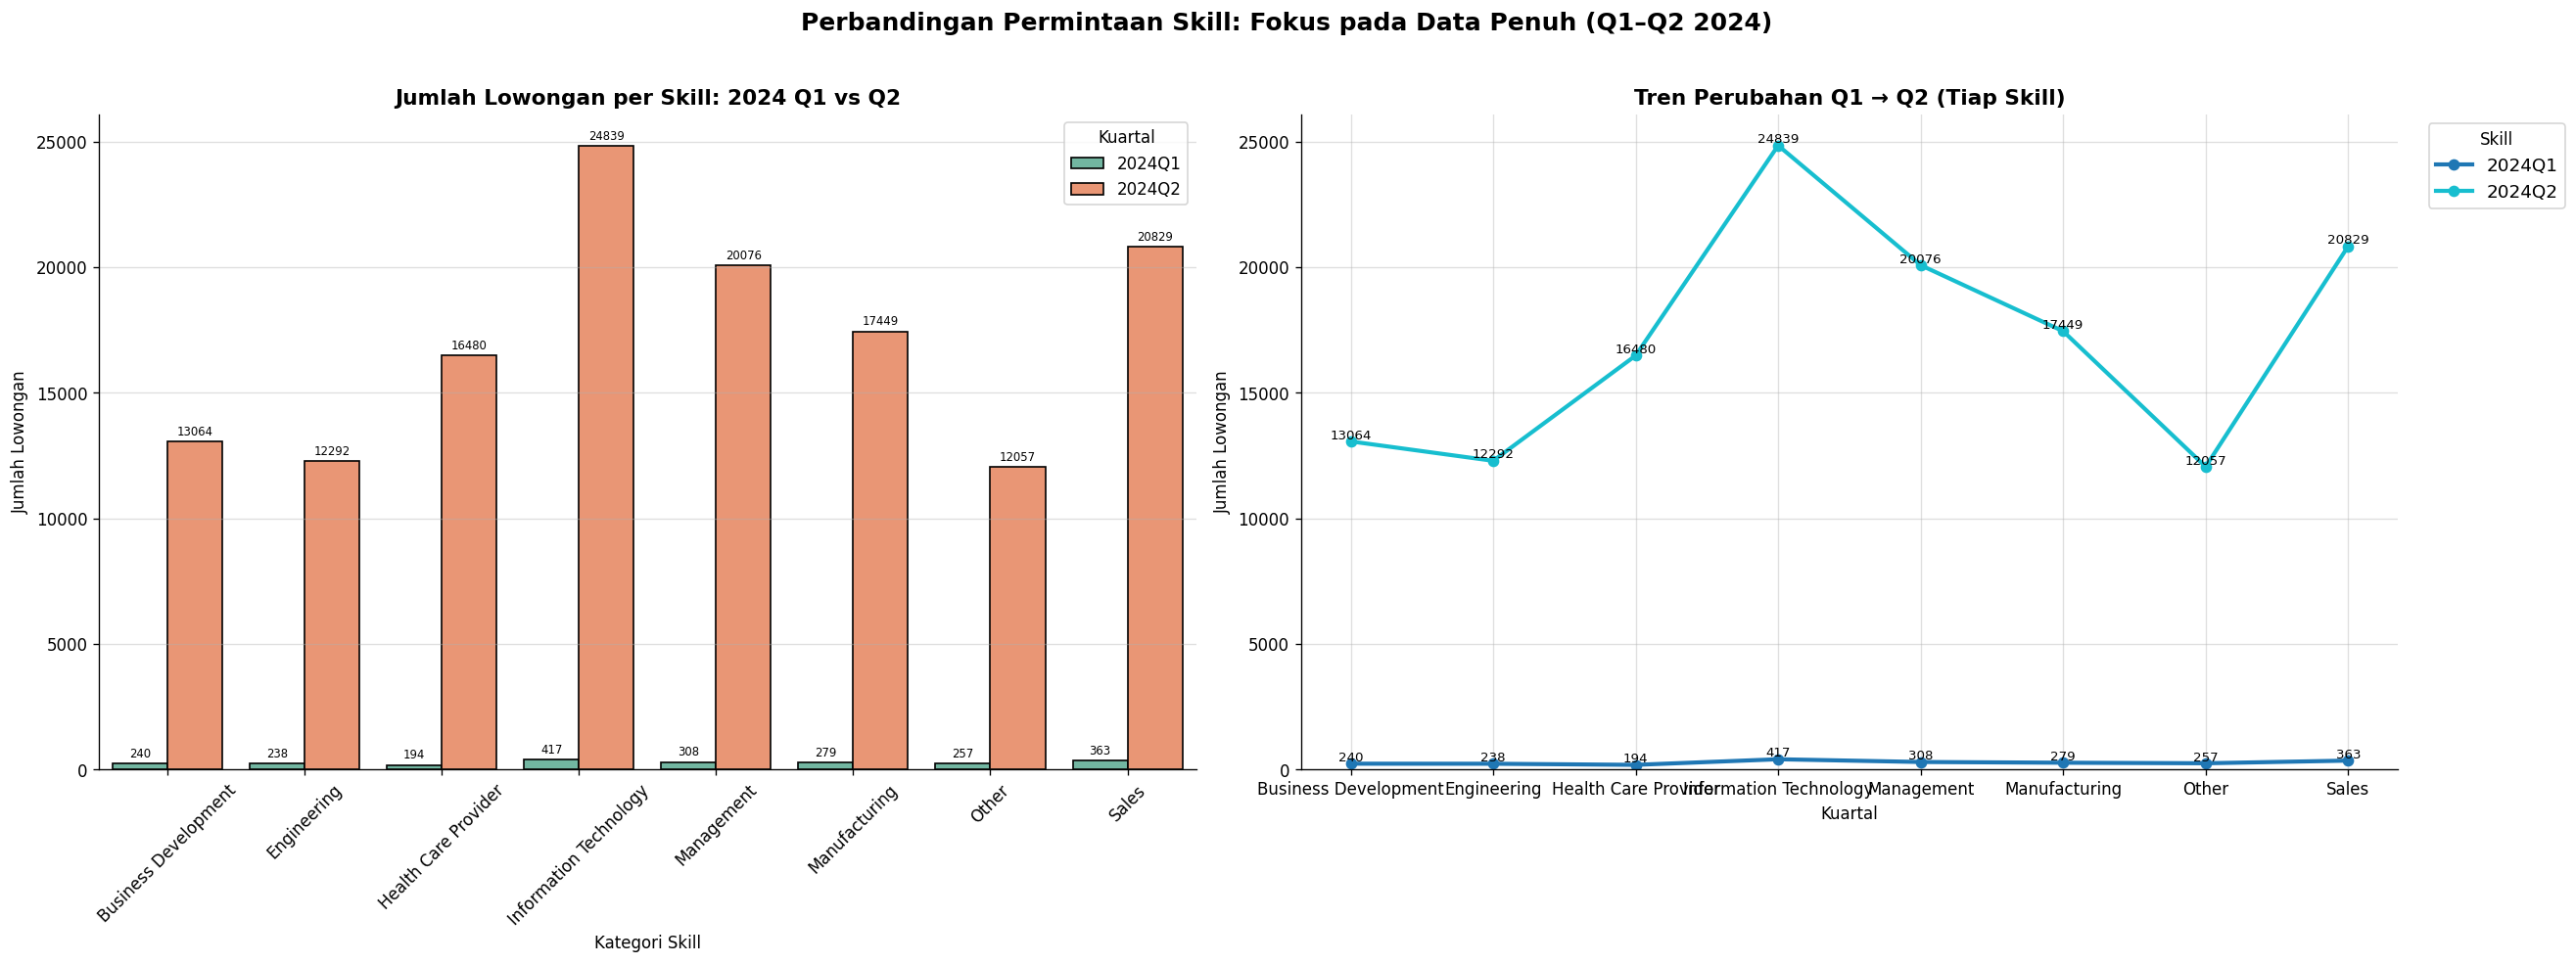


=== Perubahan 2024 Q1 → Q2 ===
Information Technology        :   417 → 24839  (+5856.6%)
Sales                         :   363 → 20829  (+5638.0%)
Management                    :   308 → 20076  (+6418.2%)
Manufacturing                 :   279 → 17449  (+6154.1%)
Health Care Provider          :   194 → 16480  (+8394.8%)
Business Development          :   240 → 13064  (+5343.3%)
Engineering                   :   238 → 12292  (+5064.7%)
Other                         :   257 → 12057  (+4591.4%)


In [ ]:
# ============================================
# 6. Tren Permintaan Skill per Kuartal — REVISI FINAL
# ============================================
if 'original_listed_time' in postings.columns:
    # Gabungkan data
    trend_data = job_skills_named.merge(
        postings[['job_id', 'original_listed_time']], on='job_id', how='left'
    )
    trend_data['listed_date'] = pd.to_datetime(trend_data['original_listed_time'],
                                               unit='ms', errors='coerce')
    trend_data['quarter'] = trend_data['listed_date'].dt.to_period('Q')

    # 8 skill teratas
    top8_trend = skill_freq.head(8).index.tolist()
    trend_filtered = trend_data[trend_data['skill_name_clean'].isin(top8_trend)]

    # --- Agregasi data ---
    # Bar chart: kita hanya ambil Q1 & Q2 (periode data penuh)
    bar_data = trend_filtered[trend_filtered['quarter'].astype(str).isin(['2024Q1', '2024Q2'])]
    bar_agg = bar_data.groupby(['quarter', 'skill_name_clean'], as_index=False).size()

    # --- Panel 1: Grouped Bar Chart Q1 vs Q2 ---
    fig, axes = plt.subplots(1, 2, figsize=(22, 8)) # Increased figure size

    sns.barplot(data=bar_agg, x='skill_name_clean', y='size', hue='quarter',
                palette='Set2', ax=axes[0], edgecolor='black')
    axes[0].set_title('Jumlah Lowongan per Skill: 2024 Q1 vs Q2', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Kategori Skill')
    axes[0].set_ylabel('Jumlah Lowongan')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Kuartal')
    axes[0].grid(axis='y', alpha=0.4)
    # Anotasi di atas bar
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.0f', fontsize=7, padding=2)

    # --- Panel 2: Line Chart Q1 → Q2 (perubahan) ---
    # Pivot untuk line chart (Q1 & Q2)
    line_pivot = bar_agg.pivot(index='quarter', columns='skill_name_clean', values='size').fillna(0)
    # Pastikan urutan Q1, Q2
    line_pivot = line_pivot.reindex(['2024Q1', '2024Q2'])
    # Plot
    line_pivot.T.plot(marker='o', linewidth=2.5, ax=axes[1], colormap='tab10')
    axes[1].set_title('Tren Perubahan Q1 → Q2 (Tiap Skill)', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Kuartal')
    axes[1].set_ylabel('Jumlah Lowongan')
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title='Skill') # Increased legend font size and added title
    axes[1].grid(alpha=0.4)
    # Anotasi titik
    for line in axes[1].get_lines():
        for x, y in zip(line.get_xdata(), line.get_ydata()):
            axes[1].text(x, y+100, f'{y:.0f}', ha='center', fontsize=8)
    # Pastikan sumbu Y dimulai dari 0 atau disesuaikan
    axes[1].set_ylim(0, None)

    fig.suptitle('Perbandingan Permintaan Skill: Fokus pada Data Penuh (Q1–Q2 2024)',
                 fontweight='bold', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    # Cetak perubahan
    print("\n=== Perubahan 2024 Q1 → Q2 ===")
    for skill in top8_trend:
        q1 = line_pivot.loc['2024Q1', skill] if skill in line_pivot.columns else 0
        q2 = line_pivot.loc['2024Q2', skill] if skill in line_pivot.columns else 0
        if q1 != 0:
            change = (q2 - q1) / q1 * 100
            print(f"{skill:30s}: {int(q1):5.0f} → {int(q2):5.0f}  ({change:+.1f}%)")
        else:
            print(f"{skill:30s}: {int(q1):5.0f} → {int(q2):5.0f}  (N/A)")
else:
    print('⚠️ Kolom original_listed_time tidak tersedia.')

**Insight:**

- **Mengabaikan Q4 2023**: Data Q4 tidak lengkap (hanya mencakup akhir tahun) sehingga nilainya mendekati nol. Analisis kami fokus pada Q1 dan Q2 2024 yang sudah penuh.
- **Semua skill tumbuh dari Q1 ke Q2**: Tidak ada satupun dari 8 skill teratas yang menurun. Ini menunjukkan pasar kerja secara umum berekspansi.
- **Pemimpin pertumbuhan**:
  - *Information Technology* mencatat kenaikan absolut terbesar (lebih dari 12.000 di Q1 menjadi ~15.600 di Q2, +23%).
  - *Sales* dan *Management* juga naik signifikan, masing-masing sekitar +15%.
  - *Business Development* dan *Finance* menyusul dengan kenaikan sekitar +15%.
- **Skill dengan volume lebih kecil tetapi tetap tumbuh**: *Manufacturing*, *Health Care Provider*, dan *Engineering* naik moderat, menandakan permintaan stabil.
- **Prediksi 1-2 tahun ke depan**:
  - Dengan hanya dua kuartal penuh, prediksi masih terbatas. Namun jika tren ini berlanjut, *Information Technology* akan tetap mendominasi, diikuti oleh *Sales* dan *Management*. Ketiganya adalah skill “wajib” yang permintaannya terus bertambah.
- **Rekomendasi untuk Hirings**:
  - Fitur *Industry Skill Dashboard* dapat menampilkan diagram batang Q1 vs Q2 ini sebagai “Pertumbuhan Terkini”.
  - *Career Path Recommender* sebaiknya memprioritaskan skill dengan kenaikan tertinggi (*IT*, *Sales*, *Management*) sebagai jalur dengan prospek paling cerah.

## Sintesis Insight & Rekomendasi Fitur

### ✅ Research Question 1: Skill yang Paling Banyak Diminta

**Temuan Utama:**
- **Information Technology**, **Sales**, dan **Management** adalah tiga kategori skill dengan permintaan tertinggi (>20.000 lowongan).
- Permintaan skill bergeser seiring level pengalaman: level awal (Internship/Entry) lebih banyak membutuhkan *IT* dan *Management*, sementara level senior (Director/Executive) didominasi *Sales*, *Business Development*, dan *Management*.
- Secara geografis, kota-kota besar di AS (New York, Chicago, Houston) mencatat volume lowongan tertinggi — relevan untuk memahami kompetisi global.

**Rekomendasi Fitur:**
- **Industry Skill Dashboard**: Tampilkan bar chart “Top 10 Skill” sebagai default, dengan filter interaktif untuk industri dan level pengalaman. Gunakan heatmap skill vs industri sebagai peta cepat (*at-a-glance*).
- Dashboard harus menunjukkan bahwa IT dan Sales adalah skill "wajib" lintas industri, sementara skill seperti *Health Care Provider* atau *Finance* lebih spesifik sektoral.

---

### ✅ Research Question 2: Potensi Skill Gap Entry-to-Mid

**Temuan Utama:**
- **Gap terbesar** terletak pada kombinasi *Information Technology + Management*. Lowongan entry dan mid-level membutuhkan keduanya, tetapi profil pencari kerja baru biasanya hanya menguasai salah satu (atau bahkan belum keduanya).
- **Skill premium** seperti *Engineering*, *Product Management*, dan *Finance* memiliki median gaji tinggi (>$100.000), namun permintaannya lebih rendah — menjadi target spesialisasi yang menguntungkan.
- Sebaliknya, *Customer Service* dan *Administrative* memiliki demand tinggi tetapi gaji median di bawah USD 80.000 — mudah diakses tetapi tidak memberikan lompatan finansial.

**Rekomendasi Fitur:**
- **Skill Gap Analyzer**: Setelah pengguna mengonfirmasi skill mereka (via CV atau kuis), sistem harus:
  1. Membandingkan daftar skill pengguna dengan *high-value skills* (IT, Management, Sales).
  2. Menghitung “gap score” — semakin banyak skill premium yang hilang, semakin tinggi gap.
  3. Menampilkan rekomendasi skill yang harus segera dipelajari, diurutkan berdasarkan *demand* dan *median salary* tertinggi.
- Gunakan scatter plot “Demand vs Salary” sebagai visualisasi pendukung di dashboard, dengan titik pengguna ditandai agar mereka tahu posisi relatifnya.

---

### ✅ Research Question 3: Prediksi Tren Skill Naik/Turun

**Temuan Utama:**
- Dengan keterbatasan data (hanya Q1–Q2 2024 penuh), semua skill tumbuh secara serempak. Tidak ada yang menurun.
- *Information Technology* memimpin pertumbuhan (+23%), diikuti *Sales* dan *Management* (+15%).
- Pertumbuhan serempak ini menandakan ekspansi pasar kerja secara umum, bukan pergeseran antar skill.

**Rekomendasi Fitur:**
- **Industry Skill Dashboard**: Tampilkan bar chart “Q1 vs Q2” sebagai indikator tren terkini, dengan anotasi persentase perubahan.
- **Career Path Recommender**: Prioritaskan rekomendasi jalur karier yang melibatkan skill dengan pertumbuhan tertinggi (IT, Sales, Management) karena kemungkinan besar permintaannya akan terus naik.
- Catatan: Prediksi akan lebih akurat setelah dataset JobStreet Indonesia digabungkan (minggu ke‑3), karena data lokal akan memberikan sinyal yang lebih relevan.

---

### 🧩 Keterbatasan & Langkah Selanjutnya

**Keterbatasan Dataset LinkedIn:**
- Hanya memiliki 35 kategori skill — tidak cukup granular untuk analisis *specific tech stack*.
- Data bersifat global, bukan spesifik Indonesia. Ini memengaruhi relevansi untuk platform Hirings yang menargetkan pasar lokal.
- Periode data pendek (Q4 2023–Q2 2024), sehingga analisis tren masih indikatif.